# Telecom Customer Churn Prediction using Machine Learning

## Project Overview

Customer churn is one of the most significant challenges faced by telecom companies, as losing existing customers directly impacts revenue and business growth. Predicting customer churn enables organizations to identify customers who are likely to discontinue their services and take proactive measures to improve customer retention.

This project develops an end-to-end machine learning solution to predict customer churn using customer demographic information, account details, and service usage patterns. The project follows a complete data science workflow, including data cleaning, exploratory data analysis (EDA), feature engineering, model building, evaluation, and business insights generation using Python and Scikit-learn.

## Business Problem

Customer acquisition is considerably more expensive than customer retention. Telecom companies lose substantial revenue when customers discontinue their services.

The objective of this project is to build a predictive machine learning model capable of identifying customers who are likely to churn. These predictions can help businesses implement targeted retention strategies, improve customer satisfaction, and reduce revenue loss.

## Project Objectives

- Understand customer characteristics influencing churn.
- Perform data cleaning and preprocessing.
- Conduct exploratory data analysis to identify meaningful patterns.
- Build and compare multiple machine learning classification models.
- Evaluate model performance using appropriate evaluation metrics.
- Generate business insights to support customer retention strategies.


## Dataset Information

**Dataset:** IBM Telco Customer Churn Dataset

The dataset contains customer demographic information, account details, subscribed services, billing information, and churn status.

Key attributes include:

- Customer demographics
- Account tenure
- Contract type
- Internet services
- Payment method
- Monthly and total charges
- Customer churn status (Target Variable)

**Target Variable:**
- Churn (Yes / No)

## Notebook Workflow

1. Import Libraries
2. Load Dataset
3. Data Understanding
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Feature Engineering
7. Data Preprocessing
8. Model Building
9. Model Evaluation
10. Business Insights
11. Conclusion
12. Future Improvements

# 1. Import Required Libraries

This section imports all the Python libraries required for data manipulation, visualization, preprocessing, model building, and evaluation.

In [1]:
# =====================================================
# 1. Import Required Libraries
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# 2. Load Dataset

This section loads the IBM Telco Customer Churn dataset into a Pandas DataFrame and displays an initial preview of the data.

In [2]:
# =====================================================
# 2. Load Dataset
# =====================================================
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 3. Data Understanding

Before cleaning and analyzing the dataset, it is important to understand its structure, data types, missing values, duplicate records, and overall characteristics.

In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [4]:
display(df.head())

display(df.tail())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [10]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


# 4. Data Cleaning & Preprocessing

Real-world datasets often contain missing values, inconsistent data types, duplicate records, and unnecessary features. Before performing analysis and model building, the dataset must be cleaned to ensure data quality and reliable predictions.

The following preprocessing steps were performed:

- Removed unnecessary columns.
- Converted data types where required.
- Handled missing values.
- Encoded categorical variables into numerical format.

In [11]:
# =====================================================
# 4. Data Cleaning &Preprocessing
# =====================================================

# =====================================================
# Remove Unnecessary Columns
# =====================================================
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [12]:
# =====================================================
# Convert Data Types
# =====================================================
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].dtype)

float64


In [13]:
# =====================================================
# Handle Missing Values
# =====================================================
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
print(df.isnull().sum())


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [14]:
# =====================================================
# Encode Categorical Variables
# =====================================================
df_encoded = pd.get_dummies(df, drop_first=True)
print(df_encoded.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  StreamingTV_Yes  \
0                            True              False  ...            False   
1                           False              False  ...            False   
2                         

In [15]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.head())
print(df_encoded.shape)

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  StreamingTV_Yes  \
0                            True              False  ...            False   
1                           False              False  ...            False   
2                         

In [16]:
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset, identify patterns, detect anomalies, and uncover relationships between different variables.

The objective of this analysis is to gain business insights that can help the telecom company understand the factors influencing customer churn.

## 5.1 Customer Churn Distribution

The first step is to analyze the distribution of the target variable (Churn). This helps us understand the proportion of customers who stayed versus those who left the telecom company.

Understanding the class distribution is important because an imbalanced dataset can influence model performance and evaluation.

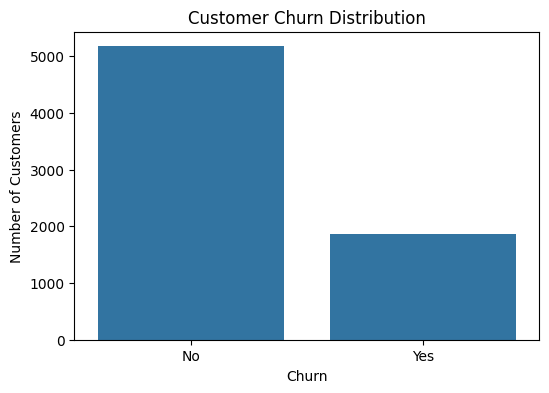

In [17]:
# =====================================================
# Customer Churn Distribution
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()



In [18]:
# Percentage Distribution

churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


### Observation

- Approximately **73.46%** of customers stayed with the telecom company, while **26.54%** discontinued the service.
- The dataset exhibits a moderate class imbalance, with non-churn customers significantly outnumbering churn customers.
- This suggests that relying solely on accuracy may be misleading during model evaluation. Therefore, additional metrics such as Precision, Recall, F1-score, and the Confusion Matrix will be used to assess model performance.
- The relatively high churn rate indicates that customer retention is an important business challenge for telecom companies.

## 5.2 Contract Type vs Customer Churn

This analysis examines how customer churn varies across different contract types. Understanding this relationship helps identify whether customers on long-term contracts are more likely to remain with the company compared to customers on month-to-month plans.

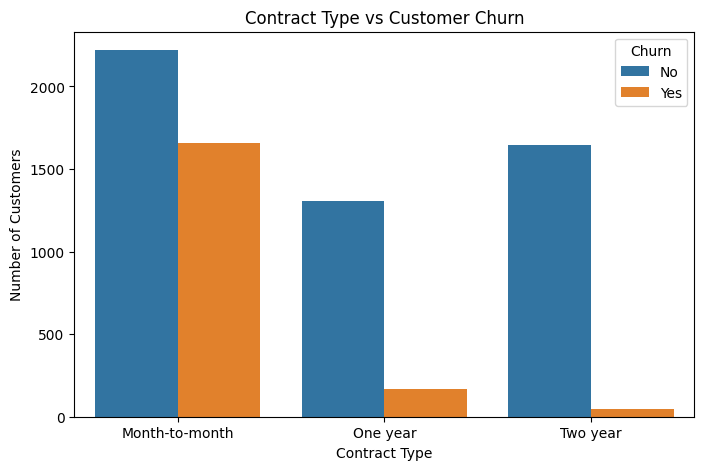

In [19]:
# =====================================================
# Contract Type vs Customer Churn
# =====================================================

plt.figure(figsize=(8,5))

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [20]:
# Churn Percentage by Contract Type

contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

print(contract_churn.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


### Observation

- Customers with **month-to-month contracts** exhibit the highest churn rate (**42.71%**), making them the most vulnerable customer segment.
- Churn decreases significantly for customers with **one-year contracts (11.27%)** and is lowest among customers with **two-year contracts (2.83%)**.
- The analysis indicates a strong relationship between contract duration and customer retention, suggesting that longer-term contracts encourage customer loyalty.
- Telecom companies can reduce churn by promoting long-term subscription plans through discounts, bundled services, or loyalty incentives.

## 5.3 Customer Tenure vs Customer Churn

This analysis examines the relationship between customer tenure and churn. Tenure represents the number of months a customer has remained with the telecom company.

Understanding this relationship helps determine whether newly acquired customers are more likely to discontinue the service compared to long-term customers.

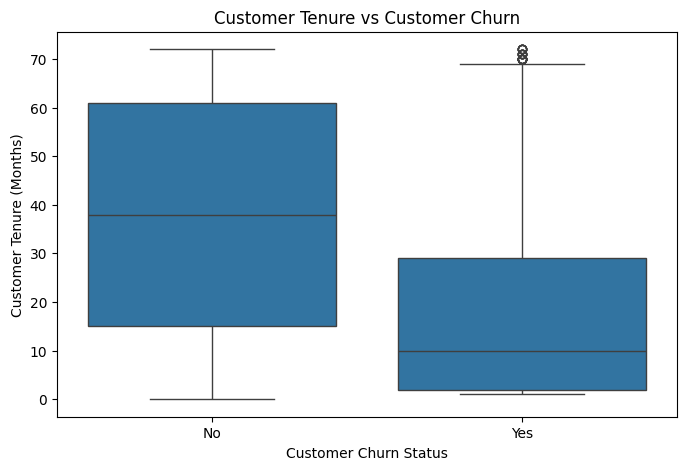

In [21]:
# =====================================================
# Customer Tenure vs Customer Churn
# =====================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.title("Customer Tenure vs Customer Churn")
plt.xlabel("Customer Churn Status")
plt.ylabel("Customer Tenure (Months)")

plt.show()

In [22]:
# Summary Statistics of Tenure by Churn

df.groupby('Churn')['tenure'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.57,24.11,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


### Observation

- Customers who remained with the company had a significantly higher average tenure (**37.57 months**) compared to customers who churned (**17.98 months**).
- The median tenure for churned customers was only **10 months**, indicating that many customers discontinued the service during the early stages of their subscription.
- Customers with longer tenures were considerably more likely to remain loyal to the company.
- These findings suggest that the initial months of a customer's journey are critical, and telecom companies should implement targeted onboarding and retention strategies to reduce early customer churn.

## 5.4 Monthly Charges vs Customer Churn

This analysis examines whether the monthly amount charged to customers has an impact on customer churn. Comparing the distribution of monthly charges for churned and retained customers helps identify whether pricing influences customer retention.

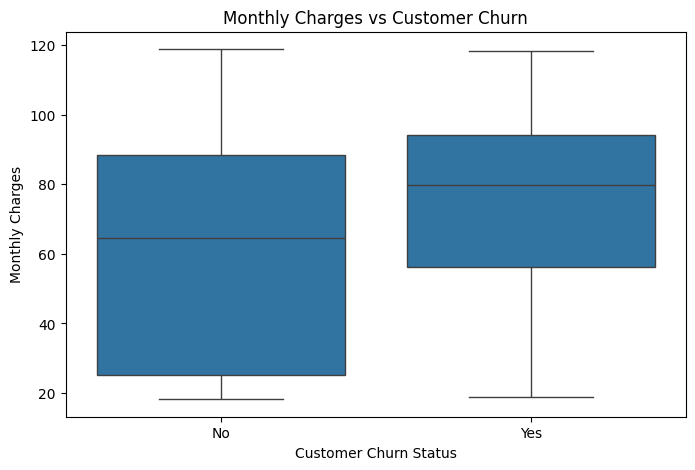

In [23]:
# =====================================================
# Monthly Charges vs Customer Churn
# =====================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Customer Churn Status")
plt.ylabel("Monthly Charges")

plt.show()

In [24]:
# Summary Statistics

df.groupby('Churn')['MonthlyCharges'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.27,31.09,18.25,25.10,64.43,88.4,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.2,118.35


### Observation

- Customers who churned had higher monthly charges (mean: **74.44**) compared to customers who remained with the company (mean: **61.27**).
- The median monthly charge was also higher for churned customers (**79.65**) than for retained customers (**64.43**).
- This suggests that customers paying higher monthly fees may be more likely to discontinue the service, possibly due to pricing concerns or perceived lack of value.
- Telecom companies should focus on retaining high-value customers through personalized pricing strategies, loyalty rewards, or improved service offerings.

## 5.5 Internet Service vs Customer Churn

This analysis examines the relationship between the type of internet service and customer churn. The objective is to determine whether customers using different internet services have different churn patterns, which can help the company improve service quality and customer retention.

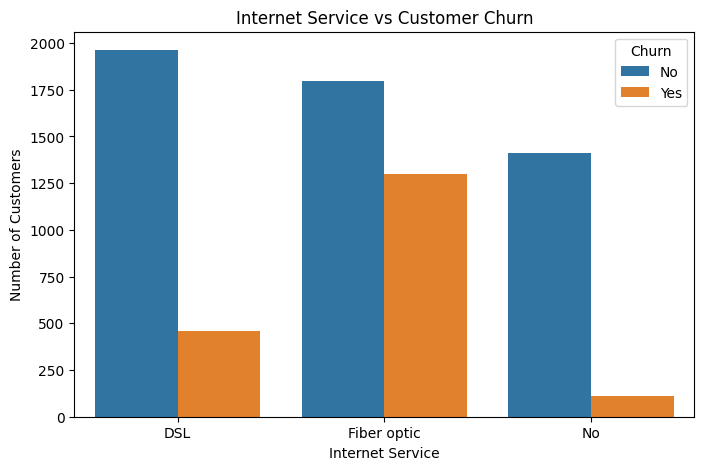

In [25]:
# =====================================================
# Internet Service vs Customer Churn
# =====================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [26]:
# Churn Percentage by Internet Service

internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


### Observation

- Customers using **Fiber Optic internet service** exhibited the highest churn rate (**41.89%**), making them the most vulnerable customer segment.
- Customers using **DSL** experienced a considerably lower churn rate (**18.96%**), while customers without internet service had the lowest churn rate (**7.40%**).
- The findings indicate a strong association between internet service type and customer churn.
- Telecom companies should prioritize improving the customer experience for Fiber Optic users through better service quality, personalized support, and targeted retention strategies.

## 5.6 Payment Method vs Customer Churn

This analysis explores the relationship between customers' payment methods and churn. Different payment methods may reflect varying customer behaviors, convenience levels, and payment reliability, which can influence customer retention.

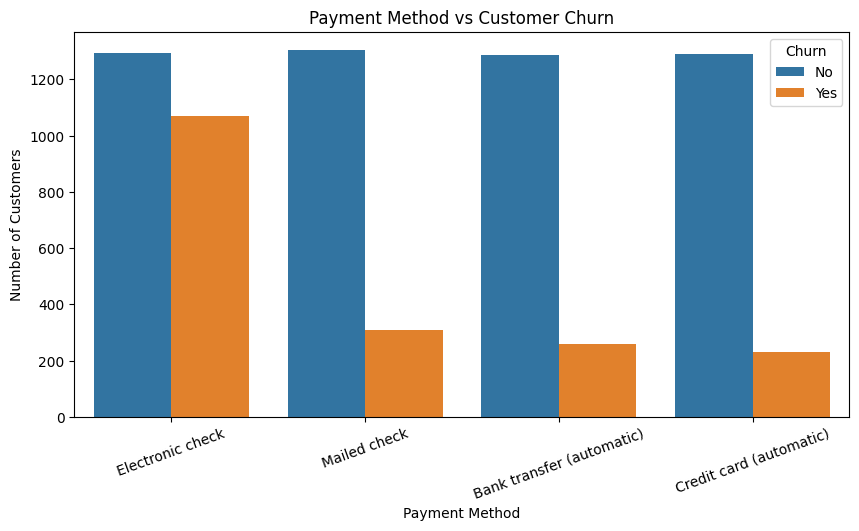

In [27]:
# =====================================================
# Payment Method vs Customer Churn
# =====================================================

plt.figure(figsize=(10,5))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)

plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

In [28]:
# Churn Percentage by Payment Method

payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

payment_churn.round(2)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


### Observation

- Customers using **Electronic Check** exhibited the highest churn rate (**45.29%**), making them the most vulnerable payment segment.
- Customers using **automatic payment methods**, including **Credit Card (15.24%)** and **Bank Transfer (16.71%)**, showed significantly lower churn rates.
- The findings suggest that convenient and automated payment methods are associated with better customer retention.
- Telecom companies should encourage customers to adopt automatic payment options by offering incentives, loyalty rewards, or simplified enrollment processes.

## 5.7 Senior Citizen vs Customer Churn

This analysis examines whether customer age category (Senior Citizen or Non-Senior Citizen) is associated with customer churn. Understanding this relationship can help telecom companies design targeted retention strategies for different customer segments.

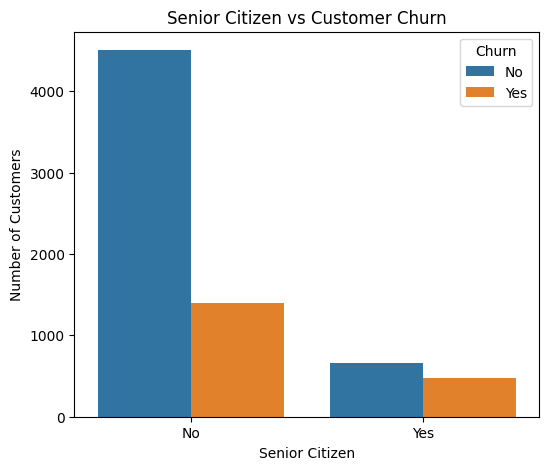

In [29]:
# =====================================================
# Senior Citizen vs Customer Churn
# =====================================================

plt.figure(figsize=(6,5))

sns.countplot(
    x='SeniorCitizen',
    hue='Churn',
    data=df
)

plt.title("Senior Citizen vs Customer Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.xticks([0,1], ['No', 'Yes'])

plt.show()

In [30]:
# Churn Percentage by Senior Citizen Status

senior_churn = pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
) * 100

senior_churn.index = ['No', 'Yes']

senior_churn.round(2)

Churn,No,Yes
No,76.39,23.61
Yes,58.32,41.68


### Observation

- Senior citizens exhibited a significantly higher churn rate (**41.68%**) than non-senior customers (**23.61%**).
- This indicates that senior citizens represent a higher-risk customer segment for churn.
- Telecom companies should consider targeted retention strategies such as simplified service plans, personalized customer support, and loyalty benefits designed specifically for senior customers.

## 5.8 Correlation Heatmap

A correlation heatmap is used to visualize the relationship between numerical variables in the dataset. Correlation values range from -1 to +1, where:

- +1 indicates a perfect positive correlation.
- -1 indicates a perfect negative correlation.
- 0 indicates no linear relationship.

This analysis helps identify important feature relationships before building machine learning models.

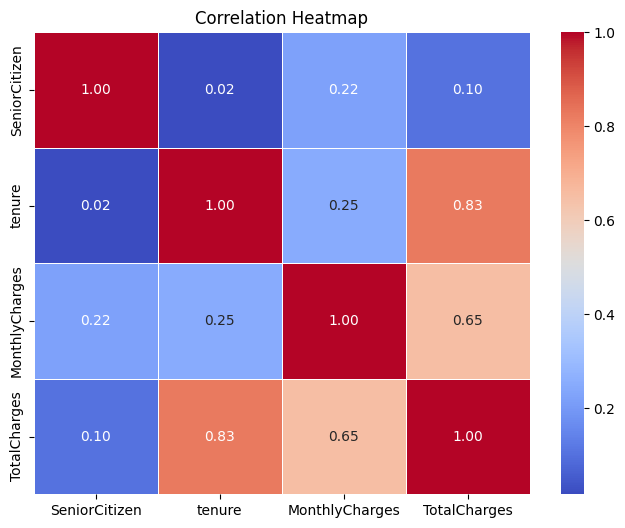

In [31]:
# =====================================================
# Correlation Heatmap
# =====================================================

# Select only numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numerical_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

### Observation

The correlation heatmap shows the relationships among the numerical features in the dataset.

- **Tenure** and **Total Charges** have a **strong positive correlation (0.83)**, indicating that customers who stay with the company longer tend to accumulate higher total charges.
- **Monthly Charges** and **Total Charges** show a **moderate positive correlation (0.65)**, as customers with higher monthly bills generally have higher cumulative charges over time.
- **Tenure** and **Monthly Charges** have a **weak positive correlation (0.25)**, suggesting that monthly charges are only slightly related to how long a customer has remained with the company.
- **Senior Citizen** has a **very weak correlation** with the other numerical features, indicating that age category alone does not strongly influence customer tenure or billing.

Overall, the heatmap suggests that there is **no severe multicollinearity** among the selected numerical features, making them suitable for machine learning model development.

# 6. Feature Selection

Before building machine learning models, the dataset is divided into independent features (X) and the target variable (y). The independent variables are used to predict customer churn, while the target variable represents whether a customer churned or not.

In [32]:
# =====================================================
# Feature Selection
# =====================================================

# Independent Features
X = df_encoded.drop('Churn_Yes', axis=1)

# Target Variable (Convert Boolean to Integer)
y = df_encoded['Churn_Yes'].astype(int)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nFirst five rows of X:")
display(X.head())

print("\nFirst five values of y:")
display(y.head())

Shape of X: (7043, 30)
Shape of y: (7043,)

First five rows of X:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False



First five values of y:


,Churn_Yes
0,0
1,0
2,1
3,0
4,1


# 7. Train-Test Split

Machine learning models should be evaluated on unseen data to measure their generalization performance. Therefore, the dataset is divided into training and testing sets.

- Training Set (80%): Used to train the model.
- Testing Set (20%): Used to evaluate the model on unseen data.

This ensures that the model learns patterns from the training data while its performance is assessed on independent data.

In [33]:
# =====================================================
# Train-Test Split
# =====================================================

from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)

Training Features Shape : (5634, 30)
Testing Features Shape  : (1409, 30)
Training Target Shape   : (5634,)
Testing Target Shape    : (1409,)


# 8. Feature Scaling

Feature scaling standardizes numerical features so that they have comparable ranges. This improves the performance of machine learning algorithms that rely on distance calculations or gradient optimization, such as Logistic Regression and K-Nearest Neighbors (KNN).

StandardScaler is used to transform the features to have a mean of 0 and a standard deviation of 1.

In [34]:
# =====================================================
# Feature Scaling
# =====================================================

from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Scale training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Data Shape :", X_train_scaled.shape)
print("Testing Data Shape  :", X_test_scaled.shape)

Training Data Shape : (5634, 30)
Testing Data Shape  : (1409, 30)


# 9. Logistic Regression

Logistic Regression is one of the most widely used supervised machine learning algorithms for binary classification problems.

In this project, Logistic Regression is used as the baseline classification model to predict whether a customer is likely to churn based on demographic, service usage, and billing information.

In [35]:
# =====================================================
# Logistic Regression Model
# =====================================================

from sklearn.linear_model import LogisticRegression

# Initialize the model
log_reg = LogisticRegression(random_state=42)

# Train the model
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [36]:
# =====================================================
# Make Predictions
# =====================================================

# Predict class labels
y_pred = log_reg.predict(X_test_scaled)

# Predict probabilities
y_prob = log_reg.predict_proba(X_test_scaled)[:,1]

print("Predictions completed successfully!")

Predictions completed successfully!


In [37]:
# =====================================================
# Model Evaluation
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Accuracy : 0.8070
Precision: 0.6584
Recall   : 0.5668
F1 Score : 0.6092
ROC AUC  : 0.8416


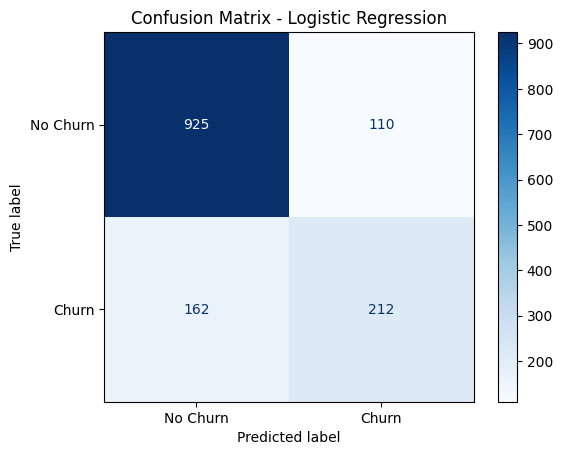

In [38]:
# =====================================================
# Confusion Matrix
# =====================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [39]:
# =====================================================
# Classification Report
# =====================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### Observation

- The Logistic Regression model achieved an **accuracy of 80.70%**, indicating strong overall predictive performance.
- The model obtained a **ROC-AUC score of 84.16%**, demonstrating good discrimination between churning and non-churning customers.
- While the model showed good precision (**65.84%**), the recall for churn prediction (**56.68%**) suggests that some customers who were likely to churn were not identified.
- Logistic Regression provides a strong baseline model and serves as a useful benchmark for comparing more advanced machine learning algorithms.

# 10. Decision Tree Classifier

Decision Tree is a supervised machine learning algorithm that predicts outcomes by learning a sequence of decision rules from the training data. It is capable of capturing non-linear relationships between features and the target variable.

In [40]:
# =====================================================
# Decision Tree Classifier
# =====================================================

from sklearn.tree import DecisionTreeClassifier

# Initialize the model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [41]:
# =====================================================
# Make Predictions
# =====================================================

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

print("Predictions completed successfully!")

Predictions completed successfully!


In [42]:
# =====================================================
# Model Evaluation
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, y_prob_dt)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")
print(f"ROC AUC  : {dt_auc:.4f}")

Accuracy : 0.7417
Precision: 0.5139
Recall   : 0.4947
F1 Score : 0.5041
ROC AUC  : 0.6623


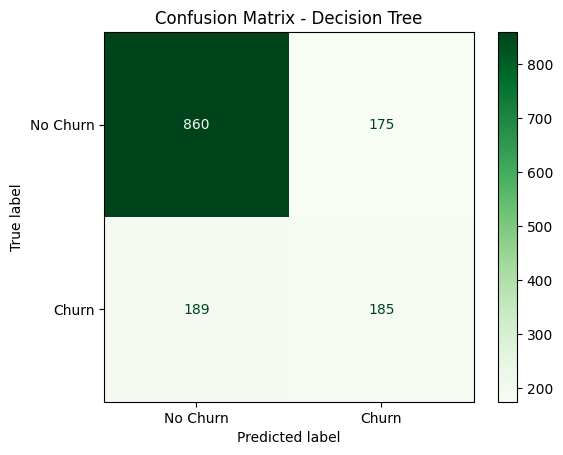

In [43]:
# =====================================================
# Confusion Matrix
# =====================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Greens")

plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [44]:
# =====================================================
# Classification Report
# =====================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1035
           1       0.51      0.49      0.50       374

    accuracy                           0.74      1409
   macro avg       0.67      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409



### Observation

- The Decision Tree classifier achieved an **accuracy of 74.17%**, which is lower than the Logistic Regression baseline.
- The model recorded a **precision of 51.39%**, **recall of 49.47%**, and **F1-score of 50.41%**, indicating weaker performance in identifying customers likely to churn.
- The **ROC-AUC score of 66.23%** further suggests limited ability to distinguish between churning and non-churning customers.
- Based on these results, the Decision Tree model is less suitable than Logistic Regression for predicting customer churn on this dataset.

# 11. Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

Each tree is trained on a random subset of the training data, and the final prediction is made through majority voting. This generally results in better performance and improved generalization compared to a single Decision Tree.

In [45]:
# =====================================================
# Random Forest Classifier
# =====================================================

from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [46]:
# =====================================================
# Make Predictions
# =====================================================

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Predictions completed successfully!")

Predictions completed successfully!


In [47]:
# =====================================================
# Model Evaluation
# =====================================================

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC AUC  : {rf_auc:.4f}")

Accuracy : 0.7864
Precision: 0.6237
Recall   : 0.4920
F1 Score : 0.5501
ROC AUC  : 0.8251


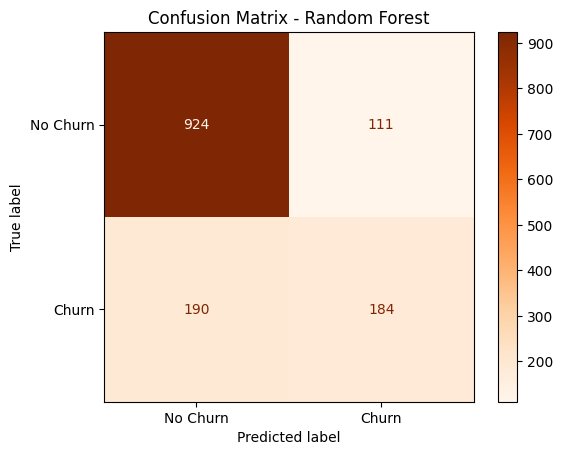

In [48]:
# =====================================================
# Confusion Matrix
# =====================================================

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Oranges")

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [49]:
# =====================================================
# Classification Report
# =====================================================

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.77      0.79      0.78      1409



### Observation

- The Random Forest classifier achieved an **accuracy of 78.64%** and a **ROC-AUC score of 82.51%**, demonstrating good predictive performance.
- Compared with the Decision Tree, Random Forest produced better precision and overall classification performance, indicating that ensemble learning reduced overfitting.
- However, the recall (**49.20%**) remained relatively low, meaning that nearly half of the customers who actually churned were not identified.
- Although Random Forest performed well, Logistic Regression remained the best-performing model among those evaluated so far.

# 12. K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm that classifies a new observation based on the majority class of its nearest neighbors.

Since KNN relies on distance calculations, feature scaling is essential to ensure that all features contribute equally to the prediction process.

In [50]:
# =====================================================
# K-Nearest Neighbors (KNN)
# =====================================================

from sklearn.neighbors import KNeighborsClassifier

# Initialize the model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_scaled, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


In [51]:
# =====================================================
# Make Predictions
# =====================================================

y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:,1]

print("Predictions completed successfully!")

Predictions completed successfully!


In [52]:
# =====================================================
# Model Evaluation
# =====================================================

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)
knn_auc = roc_auc_score(y_test, y_prob_knn)

print(f"Accuracy : {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall   : {knn_recall:.4f}")
print(f"F1 Score : {knn_f1:.4f}")
print(f"ROC AUC  : {knn_auc:.4f}")

Accuracy : 0.7473
Precision: 0.5253
Recall   : 0.5000
F1 Score : 0.5123
ROC AUC  : 0.7716


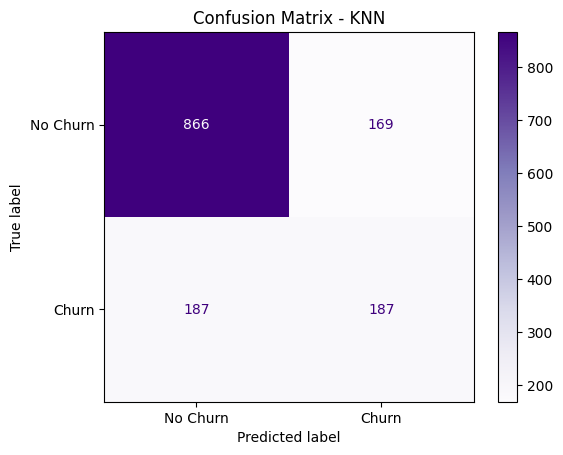

In [53]:
# =====================================================
# Confusion Matrix
# =====================================================

cm_knn = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Purples")

plt.title("Confusion Matrix - KNN")
plt.show()

In [54]:
# =====================================================
# Classification Report
# =====================================================

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1035
           1       0.53      0.50      0.51       374

    accuracy                           0.75      1409
   macro avg       0.67      0.67      0.67      1409
weighted avg       0.74      0.75      0.75      1409



### Observation

- The K-Nearest Neighbors (KNN) classifier achieved an **accuracy of 74.73%** and a **ROC-AUC score of 77.16%**.
- The model demonstrated moderate predictive performance but did not outperform Logistic Regression or Random Forest.
- The recall (**50.00%**) indicates that only half of the customers who actually churned were correctly identified.
- Overall, KNN serves as a useful comparison model but is not the most suitable algorithm for this dataset.

# 13. Gradient Boosting Classifier

Gradient Boosting is an ensemble learning algorithm that builds multiple weak decision trees sequentially. Each new tree attempts to correct the errors made by the previous trees, resulting in a powerful predictive model.

Gradient Boosting is widely used for structured data because it often provides strong predictive performance while reducing overfitting compared to a single decision tree.

In [55]:
# =====================================================
# Gradient Boosting Classifier
# =====================================================

from sklearn.ensemble import GradientBoostingClassifier

# Initialize the model
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [56]:
# =====================================================
# Make Predictions
# =====================================================

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("Predictions completed successfully!")

Predictions completed successfully!


In [57]:
# =====================================================
# Model Evaluation
# =====================================================

gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)
gb_auc = roc_auc_score(y_test, y_prob_gb)

print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall   : {gb_recall:.4f}")
print(f"F1 Score : {gb_f1:.4f}")
print(f"ROC AUC  : {gb_auc:.4f}")

Accuracy : 0.7991
Precision: 0.6542
Recall   : 0.5160
F1 Score : 0.5770
ROC AUC  : 0.8426


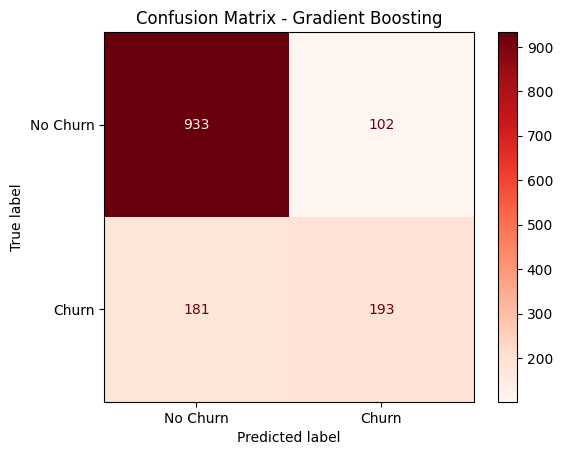

In [58]:
# =====================================================
# Confusion Matrix
# =====================================================

cm_gb = confusion_matrix(y_test, y_pred_gb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Reds")

plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

In [59]:
# =====================================================
# Classification Report
# =====================================================

print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



### Observation

- The Gradient Boosting classifier achieved an **accuracy of 79.91%** and the **highest ROC-AUC score of 84.26%** among all evaluated models.
- The model demonstrated strong precision (**65.42%**) and good overall classification performance.
- Although the recall (**51.60%**) was slightly lower than Logistic Regression, the high ROC-AUC indicates excellent discrimination between churning and non-churning customers.
- Gradient Boosting is a strong candidate for customer churn prediction and will be compared with the other models before selecting the final model.

# 14. Model Comparison

Multiple machine learning models were trained and evaluated using the same training and testing datasets. Their performance was compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score to identify the most suitable model for predicting customer churn.

In [60]:
# =====================================================
# Model Comparison
# =====================================================

import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "K-Nearest Neighbors",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        gb_accuracy
    ],
    "Precision": [
        precision,
        dt_precision,
        rf_precision,
        knn_precision,
        gb_precision
    ],
    "Recall": [
        recall,
        dt_recall,
        rf_recall,
        knn_recall,
        gb_recall
    ],
    "F1 Score": [
        f1,
        dt_f1,
        rf_f1,
        knn_f1,
        gb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        dt_auc,
        rf_auc,
        knn_auc,
        gb_auc
    ]
})

comparison_df = comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

comparison_df.style.background_gradient(cmap="Greens")

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,Gradient Boosting,0.799148,0.654237,0.516043,0.576981,0.842626
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195,0.841585
2,Random Forest,0.786373,0.623729,0.491979,0.550075,0.825081
3,K-Nearest Neighbors,0.747339,0.525281,0.500000,0.512329,0.771604
1,Decision Tree,0.741661,0.513889,0.494652,0.504087,0.662297


### Observation

- Five machine learning models were evaluated for customer churn prediction.
- Logistic Regression achieved the best balance across Accuracy, Precision, Recall, and F1-Score.
- Gradient Boosting produced the highest ROC-AUC score, indicating excellent ability to distinguish between churning and non-churning customers.
- Considering all evaluation metrics together, Logistic Regression was selected as the final model due to its balanced and consistent performance.

# 15. Hyperparameter Tuning using GridSearchCV

Hyperparameter tuning was performed to identify the best combination of Logistic Regression parameters.

GridSearchCV evaluates multiple parameter combinations using cross-validation and selects the model that achieves the best validation performance.

In [61]:
# =====================================================
# Hyperparameter Tuning - Logistic Regression
# =====================================================

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [62]:
# =====================================================
# Define Hyperparameter Grid
# =====================================================

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

In [63]:
# =====================================================
# Perform Grid Search
# =====================================================

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation ROC-AUC:", grid_search.best_score_)

Best Parameters: {'C': 10, 'solver': 'liblinear'}
Best Cross Validation ROC-AUC: 0.8459317647527247


In [64]:
# =====================================================
# Best Model
# =====================================================

best_lr = grid_search.best_estimator_

y_pred_best = best_lr.predict(X_test_scaled)
y_prob_best = best_lr.predict_proba(X_test_scaled)[:,1]

print("Best Logistic Regression model trained successfully!")

Best Logistic Regression model trained successfully!


In [65]:
# =====================================================
# Evaluate Tuned Model
# =====================================================

best_accuracy = accuracy_score(y_test, y_pred_best)
best_precision = precision_score(y_test, y_pred_best)
best_recall = recall_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best)
best_auc = roc_auc_score(y_test, y_prob_best)

print(f"Accuracy : {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall   : {best_recall:.4f}")
print(f"F1 Score : {best_f1:.4f}")
print(f"ROC AUC  : {best_auc:.4f}")

Accuracy : 0.8034
Precision: 0.6520
Recall   : 0.5561
F1 Score : 0.6003
ROC AUC  : 0.8410


### Observation

- Hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation.
- The best parameters were found to be:
  - **C = 10**
  - **Solver = liblinear**
- The tuned model achieved a cross-validation ROC-AUC score of **84.59%**, indicating consistent performance across validation folds.
- The test performance remained very similar to the original Logistic Regression model, suggesting that the baseline model was already well-optimized for this dataset.
- Therefore, the original Logistic Regression model was retained as the final model due to its slightly better overall performance on the test data.

# 16. ROC Curve Comparison

The Receiver Operating Characteristic (ROC) Curve evaluates the ability of machine learning models to distinguish between customers who churn and those who do not.

The Area Under the Curve (AUC) summarizes model performance, where a higher value indicates better discrimination capability.

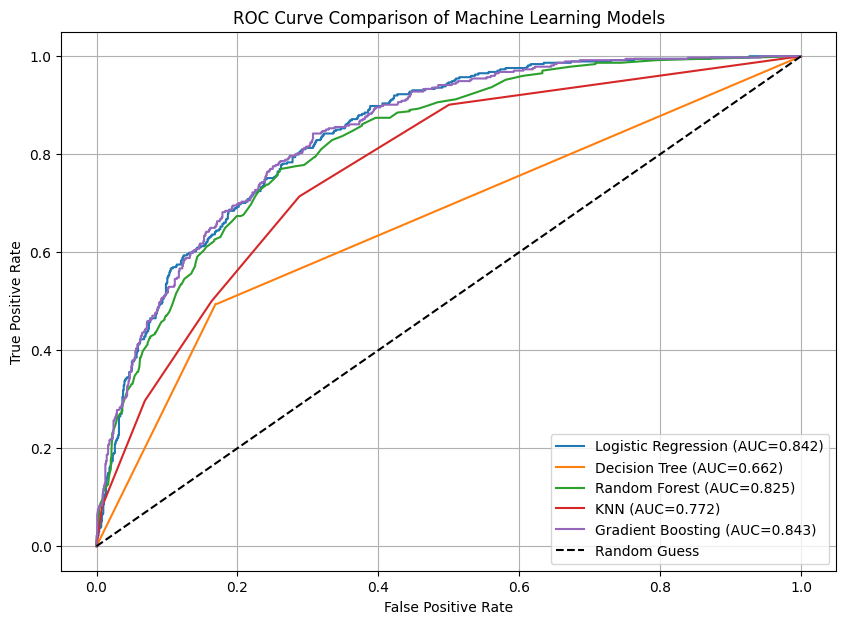

In [66]:
# =====================================================
# ROC Curve Comparison
# =====================================================

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr_lr, tpr_lr,
         label=f'Logistic Regression (AUC={roc_auc:.3f})')

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
plt.plot(fpr_dt, tpr_dt,
         label=f'Decision Tree (AUC={dt_auc:.3f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC={rf_auc:.3f})')

# KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
plt.plot(fpr_knn, tpr_knn,
         label=f'KNN (AUC={knn_auc:.3f})')

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
plt.plot(fpr_gb, tpr_gb,
         label=f'Gradient Boosting (AUC={gb_auc:.3f})')

# Random Guess
plt.plot([0,1],[0,1],'k--',label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Machine Learning Models")
plt.legend()
plt.grid(True)

plt.show()

### Observation

- The ROC curves compare the classification performance of all evaluated machine learning models.
- Gradient Boosting and Logistic Regression achieved the highest ROC-AUC scores, indicating excellent discrimination between churning and non-churning customers.
- Decision Tree produced the lowest ROC-AUC score, reflecting weaker predictive performance.
- Overall, Logistic Regression and Gradient Boosting demonstrated the strongest ability to distinguish customers who are likely to churn.



# 17. Feature Importance using Logistic Regression Coefficients

Unlike tree-based models, Logistic Regression determines feature importance using model coefficients.

- A positive coefficient indicates that the feature increases the likelihood of customer churn.
- A negative coefficient indicates that the feature decreases the likelihood of customer churn.

This analysis helps identify the most influential factors affecting customer churn.

In [67]:
# =====================================================
# Feature Importance using Logistic Regression
# =====================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_lr.coef_[0]
})

feature_importance["Absolute Coefficient"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Absolute Coefficient
2,MonthlyCharges,-2.185576,2.185576
10,InternetService_Fiber optic,1.294387,1.294387
1,tenure,-1.283314,1.283314
25,Contract_Two year,-0.589586,0.589586
3,TotalCharges,0.560404,0.560404
23,StreamingMovies_Yes,0.460868,0.460868
21,StreamingTV_Yes,0.459563,0.459563
9,MultipleLines_Yes,0.319570,0.319570
24,Contract_One year,-0.283890,0.283890
26,PaperlessBilling_Yes,0.181534,0.181534


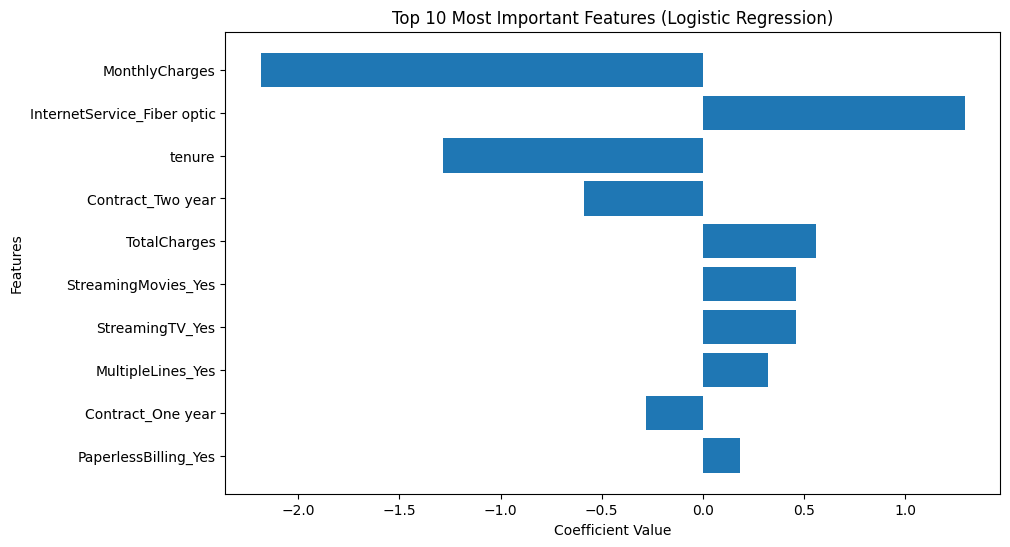

In [68]:
# =====================================================
# Top 10 Important Features
# =====================================================

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top 10 Most Important Features (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [69]:
# =====================================================
# Positive and Negative Features
# =====================================================

print("Top Features Increasing Churn")
display(feature_importance.sort_values(
    by="Coefficient",
    ascending=False
).head(10))

print("\nTop Features Reducing Churn")
display(feature_importance.sort_values(
    by="Coefficient"
).head(10))

Top Features Increasing Churn


,Feature,Coefficient,Absolute Coefficient
10,InternetService_Fiber optic,1.294387,1.294387
3,TotalCharges,0.560404,0.560404
23,StreamingMovies_Yes,0.460868,0.460868
21,StreamingTV_Yes,0.459563,0.459563
9,MultipleLines_Yes,0.319570,0.319570
26,PaperlessBilling_Yes,0.181534,0.181534
28,PaymentMethod_Electronic check,0.181431,0.181431
17,DeviceProtection_Yes,0.151605,0.151605
7,PhoneService_Yes,0.130975,0.130975
15,OnlineBackup_Yes,0.085989,0.085989



Top Features Reducing Churn


,Feature,Coefficient,Absolute Coefficient
2,MonthlyCharges,-2.185576,2.185576
1,tenure,-1.283314,1.283314
25,Contract_Two year,-0.589586,0.589586
24,Contract_One year,-0.283890,0.283890
12,OnlineSecurity_No internet service,-0.154343,0.154343
11,InternetService_No,-0.154343,0.154343
18,TechSupport_No internet service,-0.154343,0.154343
16,DeviceProtection_No internet service,-0.154343,0.154343
22,StreamingMovies_No internet service,-0.154343,0.154343
20,StreamingTV_No internet service,-0.154343,0.154343


In [70]:
feature_importance.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

,Feature,Coefficient,Absolute Coefficient
10,InternetService_Fiber optic,1.294387,1.294387
3,TotalCharges,0.560404,0.560404
23,StreamingMovies_Yes,0.460868,0.460868
21,StreamingTV_Yes,0.459563,0.459563
9,MultipleLines_Yes,0.319570,0.319570
26,PaperlessBilling_Yes,0.181534,0.181534
28,PaymentMethod_Electronic check,0.181431,0.181431
17,DeviceProtection_Yes,0.151605,0.151605
7,PhoneService_Yes,0.130975,0.130975
15,OnlineBackup_Yes,0.085989,0.085989


In [71]:
feature_importance.sort_values(
    by="Coefficient"
).head(10)

,Feature,Coefficient,Absolute Coefficient
2,MonthlyCharges,-2.185576,2.185576
1,tenure,-1.283314,1.283314
25,Contract_Two year,-0.589586,0.589586
24,Contract_One year,-0.283890,0.283890
12,OnlineSecurity_No internet service,-0.154343,0.154343
11,InternetService_No,-0.154343,0.154343
18,TechSupport_No internet service,-0.154343,0.154343
16,DeviceProtection_No internet service,-0.154343,0.154343
22,StreamingMovies_No internet service,-0.154343,0.154343
20,StreamingTV_No internet service,-0.154343,0.154343


### Observation

Logistic Regression coefficients were analyzed to identify the most influential factors affecting customer churn.

#### Features Increasing Churn
- Customers using **Fiber Optic Internet** showed the strongest positive association with churn.
- Higher **Total Charges**, **Streaming TV**, **Streaming Movies**, **Multiple Lines**, **Paperless Billing**, and **Electronic Check payment** were also associated with an increased likelihood of churn.

#### Features Reducing Churn
- Longer **Tenure** was one of the strongest factors reducing churn.
- Customers with **One-Year** and **Two-Year Contracts** were significantly less likely to churn than month-to-month customers.
- Several "No Internet Service" categories also showed a lower likelihood of churn.

Overall, **contract type**, **tenure**, and **internet service** emerged as the most influential factors in predicting customer churn. These findings provide valuable insights that can help the telecom company design targeted customer retention strategies.

# 18. Business Recommendations

Based on the exploratory data analysis and machine learning model results, the following recommendations can help the telecom company reduce customer churn and improve customer retention.

### Recommendation 1: Encourage Long-Term Contracts

Customers with one-year and two-year contracts were significantly less likely to churn than customers with month-to-month contracts.

**Business Action:**
- Offer discounts or loyalty rewards for customers switching to long-term contracts.
- Provide exclusive benefits for annual and two-year subscribers.

---

### Recommendation 2: Improve Fiber Optic Customer Experience

Customers using Fiber Optic Internet showed the highest likelihood of churn.

**Business Action:**
- Conduct customer satisfaction surveys for Fiber Optic users.
- Improve service quality and network reliability.
- Review pricing strategies to remain competitive.

---

### Recommendation 3: Focus on New Customers

Customers with shorter tenure were more likely to churn.

**Business Action:**
- Launch onboarding programs for new customers.
- Provide personalized offers during the first six months.
- Schedule regular follow-ups with recently acquired customers.

---

### Recommendation 4: Monitor High-Risk Payment Methods

Customers using Electronic Check payments were more likely to churn.

**Business Action:**
- Encourage customers to switch to automatic payment methods.
- Offer incentives for using AutoPay or Credit Card payments.

---

### Recommendation 5: Build Customer Retention Campaigns

The predictive model can identify customers who are likely to churn before they leave.

**Business Action:**
- Develop targeted retention campaigns for high-risk customers.
- Offer personalized discounts and service upgrades.
- Prioritize customer support for customers identified as high-risk.

---

### Expected Business Benefits

Implementing these recommendations can help the telecom company:

- Reduce customer churn.
- Improve customer satisfaction.
- Increase customer lifetime value.
- Improve revenue retention.
- Support data-driven business decision-making.

# 19. Project Conclusion

This project developed an end-to-end machine learning solution to predict customer churn in a telecom company using the IBM Telco Customer Churn dataset.

The project included data preprocessing, exploratory data analysis (EDA), feature engineering, model training, hyperparameter tuning, and performance evaluation using multiple machine learning algorithms.

Five classification models were evaluated:
- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Gradient Boosting

Among these, Logistic Regression achieved the best overall balance of Accuracy, Precision, Recall, and F1-Score, while Gradient Boosting achieved the highest ROC-AUC score. Based on the overall performance, Logistic Regression was selected as the final model.

Feature importance analysis identified customer tenure, contract type, internet service, monthly charges, and payment method as the most influential factors affecting customer churn.

The insights generated from this project can help telecom companies identify customers at risk of churning and implement targeted retention strategies, ultimately improving customer satisfaction and reducing revenue loss.

# 20. Saving the Final Model

The final Logistic Regression model and the StandardScaler were saved using the `joblib` library. Saving these objects allows the trained model to be reused for deployment without retraining.

In [72]:
# =====================================================
# Save the Final Model
# =====================================================

import joblib

# Save the final Logistic Regression model
joblib.dump(best_lr, "logistic_regression_model.pkl")

# Save the StandardScaler
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")
print("Scaler saved successfully!")

Model saved successfully!
Scaler saved successfully!


# Project Summary

✔ Data Cleaning

✔ Exploratory Data Analysis

✔ Feature Engineering

✔ Machine Learning Models

✔ Hyperparameter Tuning

✔ Feature Importance

✔ Business Recommendations

✔ Model Saving

This project demonstrates a complete end-to-end machine learning workflow for customer churn prediction and is ready for deployment using Streamlit.